In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

RANDOM_STATE = 42
TEST_SIZE = 0.30

In [11]:
data_path = Path("lifecycle/data/raw/risco_credito.csv")
if not data_path.exists():
    data_path = Path("data/raw/risco_credito.csv")

credit = pd.read_csv(data_path)
display(credit)
display(credit.dtypes)

,cliente_id,nome,data_cadastro,idade,renda_mensal,estado_civil,numero_dependentes,valor_emprestimo,score_credito,ultima_compra,canal_aquisicao,tempo_emprego_anos,inadimplente
0,1,Ana,2021-03-10,29.00,3500,Solteiro,0.00,10000,720,2023-10-01,Instagram,3,0
1,2,Carlos,2020-07-22,45.00,8000,Casado,2.00,20000,680,2023-06-15,Google,15,0
2,3,Mariana,2022-01-05,NaN,"""4500""",Divorciado,1.00,15000,590,2023-11-20,Facebook,5,1
3,4,João,2019-11-30,38.00,?,Casado,3.00,30000,610,2023-01-10,Indicação,10,1
4,5,Paula,2023-05-14,26.00,2800,Solteiro,0.00,5000,730,NaN,Instagram,1,0
5,6,Ricardo,2021-09-18,52.00,12000,Casado,2.00,40000,540,2023-08-02,Google,25,1
6,7,Beatriz,2022-12-01,31.00,3900,Solteiro,NaN,12000,710,2023-09-12,Facebook,4,0
7,8,Fernando,2020-04-25,47.00,9500,Casado,2.00,25000,580,2023-05-19,Indicação,20,1
8,9,Juliana,2023-02-10,34.00,4100,Solteiro,1.00,8000,690,2023-12-01,Instagram,6,0
9,10,Roberto,2018-08-09,60.00,15000,Casado,4.00,50000,520,2022-12-15,Google,30,1


cliente_id              int64
nome                      str
data_cadastro             str
idade                 float64
renda_mensal              str
estado_civil              str
numero_dependentes    float64
valor_emprestimo        int64
score_credito           int64
ultima_compra             str
canal_aquisicao           str
tempo_emprego_anos      int64
inadimplente            int64
dtype: object

# Data type and missing datapoints considerations

- `data_cadastro` and `ultima_compra` are parsed as dates.
- `idade`, `renda_mensal`, and `numero_dependentes` are coerced to numeric, with invalid entries converted to missing values.
- `idade` and `numero_dependentes` are restored as integer-like columns after imputation.

In [12]:
clean = credit.copy()

date_cols = ["data_cadastro", "ultima_compra"]
categorical_feature_cols = ["estado_civil", "canal_aquisicao"]
numerical_cols = [
    "idade",
    "renda_mensal",
    "numero_dependentes",
    "valor_emprestimo",
    "score_credito",
    "tempo_emprego_anos",
]

for col in date_cols:
    clean[col] = pd.to_datetime(clean[col], errors="coerce")

for col in categorical_feature_cols:
    clean[col] = clean[col].astype("string").str.strip()

for col in numerical_cols:
    clean[col] = (
        clean[col]
        .astype("string")
        .str.strip()
        .str.replace('"', "", regex=False)
        .replace({"?": pd.NA, "": pd.NA})
    )
    clean[col] = pd.to_numeric(clean[col], errors="coerce")

clean["inadimplente"] = pd.to_numeric(clean["inadimplente"], errors="coerce").astype(
    "Int64"
)

missing_report = (
    clean[date_cols + numerical_cols].isna().sum().rename("missing_values").to_frame()
)

display(clean.dtypes)
display(missing_report)
display(clean)

cliente_id                     int64
nome                             str
data_cadastro         datetime64[us]
idade                        Float64
renda_mensal                   Int64
estado_civil                  string
numero_dependentes           Float64
valor_emprestimo               Int64
score_credito                  Int64
ultima_compra         datetime64[us]
canal_aquisicao               string
tempo_emprego_anos             Int64
inadimplente                   Int64
dtype: object

,missing_values
data_cadastro,0
ultima_compra,1
idade,1
renda_mensal,1
numero_dependentes,1
valor_emprestimo,0
score_credito,0
tempo_emprego_anos,0


,cliente_id,nome,data_cadastro,idade,renda_mensal,estado_civil,numero_dependentes,valor_emprestimo,score_credito,ultima_compra,canal_aquisicao,tempo_emprego_anos,inadimplente
0,1,Ana,2021-03-10,29.00,3500,Solteiro,0.00,10000,720,2023-10-01,Instagram,3,0
1,2,Carlos,2020-07-22,45.00,8000,Casado,2.00,20000,680,2023-06-15,Google,15,0
2,3,Mariana,2022-01-05,<NA>,4500,Divorciado,1.00,15000,590,2023-11-20,Facebook,5,1
3,4,João,2019-11-30,38.00,<NA>,Casado,3.00,30000,610,2023-01-10,Indicação,10,1
4,5,Paula,2023-05-14,26.00,2800,Solteiro,0.00,5000,730,NaT,Instagram,1,0
5,6,Ricardo,2021-09-18,52.00,12000,Casado,2.00,40000,540,2023-08-02,Google,25,1
6,7,Beatriz,2022-12-01,31.00,3900,Solteiro,<NA>,12000,710,2023-09-12,Facebook,4,0
7,8,Fernando,2020-04-25,47.00,9500,Casado,2.00,25000,580,2023-05-19,Indicação,20,1
8,9,Juliana,2023-02-10,34.00,4100,Solteiro,1.00,8000,690,2023-12-01,Instagram,6,0
9,10,Roberto,2018-08-09,60.00,15000,Casado,4.00,50000,520,2022-12-15,Google,30,1


# Cleaning/inputting considerations

- `idade` is imputed with KNN using `estado_civil` and `tempo_emprego_anos`.
- `renda_mensal` is imputed with KNN using `tempo_emprego_anos`.
- `numero_dependentes` is imputed with KNN using `estado_civil` and the already-imputed `idade`.
- `ultima_compra` is dropped after the cleaning stage.

In [16]:
def knn_impute_column(
    df, target_col, feature_cols, n_neighbors=3, integer_output=False
):
    feature_frame = pd.get_dummies(df[feature_cols], drop_first=False, dtype=float)
    feature_frame = feature_frame.fillna(feature_frame.mean(numeric_only=True))

    known_mask = df[target_col].notna()
    missing_mask = ~known_mask

    if not missing_mask.any():
        return df.copy()

    scaler = StandardScaler()
    x_train = scaler.fit_transform(feature_frame.loc[known_mask])
    x_missing = scaler.transform(feature_frame.loc[missing_mask])
    y_train = pd.to_numeric(df.loc[known_mask, target_col], errors="coerce").astype(
        float
    )

    model = KNeighborsRegressor(n_neighbors=min(n_neighbors, len(y_train)))
    model.fit(x_train, y_train)
    imputed_values = model.predict(x_missing)

    result = df.copy()

    if integer_output:
        result[target_col] = pd.to_numeric(result[target_col], errors="coerce").astype(
            "Float64"
        )
        result.loc[missing_mask, target_col] = np.rint(imputed_values)
    else:
        result[target_col] = pd.to_numeric(result[target_col], errors="coerce").astype(
            "Float64"
        )
        result.loc[missing_mask, target_col] = imputed_values.astype(float)

    return result


imputed = knn_impute_column(
    clean, "idade", ["estado_civil", "tempo_emprego_anos"], integer_output=True
)
imputed = knn_impute_column(
    imputed, "renda_mensal", ["tempo_emprego_anos"], integer_output=False
)
imputed = knn_impute_column(
    imputed, "numero_dependentes", ["estado_civil", "idade"], integer_output=True
)

imputed["idade"] = imputed["idade"].astype("Int64")
imputed["numero_dependentes"] = imputed["numero_dependentes"].astype("Int64")

display(
    imputed[["nome", "idade", "renda_mensal", "numero_dependentes", "ultima_compra"]]
)

for col in categorical_feature_cols + ["inadimplente"]:
    print(f"Proportions for {col}:")
    print(imputed[col].value_counts(normalize=True, dropna=False))
    print()

display(imputed[numerical_cols].describe().T)

,nome,idade,renda_mensal,numero_dependentes,ultima_compra
0,Ana,29,3500.00,0,2023-10-01
1,Carlos,45,8000.00,2,2023-06-15
2,Mariana,31,4500.00,1,2023-11-20
3,João,38,5533.33,3,2023-01-10
4,Paula,26,2800.00,0,NaT
5,Ricardo,52,12000.00,2,2023-08-02
6,Beatriz,31,3900.00,0,2023-09-12
7,Fernando,47,9500.00,2,2023-05-19
8,Juliana,34,4100.00,1,2023-12-01
9,Roberto,60,15000.00,4,2022-12-15


Proportions for estado_civil:
estado_civil
Casado       0.50
Solteiro     0.40
Divorciado   0.10
Name: proportion, dtype: Float64

Proportions for canal_aquisicao:
canal_aquisicao
Instagram   0.30
Google      0.30
Facebook    0.20
Indicação   0.20
Name: proportion, dtype: Float64

Proportions for inadimplente:
inadimplente
0   0.50
1   0.50
Name: proportion, dtype: Float64



,count,mean,std,min,25%,50%,75%,max
idade,10.00,39.30,11.22,26.00,31.00,36.00,46.50,60.00
renda_mensal,10.00,6883.33,4115.35,2800.00,3950.00,5016.67,9125.00,15000.00
numero_dependentes,10.00,1.50,1.35,0.00,0.25,1.50,2.00,4.00
valor_emprestimo,10.00,21500.00,14759.18,5000.00,10500.00,17500.00,28750.00,50000.00
score_credito,10.00,637.00,78.04,520.00,582.50,645.00,705.00,730.00
tempo_emprego_anos,10.00,11.90,10.12,1.00,4.25,8.00,18.75,30.00


# Featurization considerations

- `estado_civil` and `canal_aquisicao` are one-hot encoded.
- `cliente_id` and `nome` are dropped as non-predictive identifiers.
- `data_cadastro` is transformed into `periodo_como_cliente`, the number of days since the client registered.
- The notebook keeps both raw and standardized feature matrices.

In [18]:
model_df = imputed.drop(columns=["ultima_compra"]).copy()
reference_date = pd.Timestamp.today().normalize()
model_df["dias_como_cliente"] = (reference_date - model_df["data_cadastro"]).dt.days
model_df = model_df.drop(columns=["cliente_id", "nome", "data_cadastro"])

X_raw = pd.get_dummies(
    model_df.drop(columns=["inadimplente"]),
    columns=categorical_feature_cols,
    drop_first=False,
    dtype=int,
)
y = model_df["inadimplente"].astype(int)

full_scaler = StandardScaler()
X_normalized = pd.DataFrame(
    full_scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index,
)

display(model_df)
display(X_raw.head())
display(X_normalized.head())

,idade,renda_mensal,estado_civil,numero_dependentes,valor_emprestimo,score_credito,canal_aquisicao,tempo_emprego_anos,inadimplente,dias_como_cliente
0,29,3500.00,Solteiro,0,10000,720,Instagram,3,0,1819
1,45,8000.00,Casado,2,20000,680,Google,15,0,2050
2,31,4500.00,Divorciado,1,15000,590,Facebook,5,1,1518
3,38,5533.33,Casado,3,30000,610,Indicação,10,1,2285
4,26,2800.00,Solteiro,0,5000,730,Instagram,1,0,1024
5,52,12000.00,Casado,2,40000,540,Google,25,1,1627
6,31,3900.00,Solteiro,0,12000,710,Facebook,4,0,1188
7,47,9500.00,Casado,2,25000,580,Indicação,20,1,2138
8,34,4100.00,Solteiro,1,8000,690,Instagram,6,0,1117
9,60,15000.00,Casado,4,50000,520,Google,30,1,2763


,idade,renda_mensal,numero_dependentes,valor_emprestimo,score_credito,tempo_emprego_anos,dias_como_cliente,estado_civil_Casado,estado_civil_Divorciado,estado_civil_Solteiro,canal_aquisicao_Facebook,canal_aquisicao_Google,canal_aquisicao_Indicação,canal_aquisicao_Instagram
0,29,3500.00,0,10000,720,3,1819,0,0,1,0,0,0,1
1,45,8000.00,2,20000,680,15,2050,1,0,0,0,1,0,0
2,31,4500.00,1,15000,590,5,1518,0,1,0,1,0,0,0
3,38,5533.33,3,30000,610,10,2285,1,0,0,0,0,1,0
4,26,2800.00,0,5000,730,1,1024,0,0,1,0,0,0,1


,idade,renda_mensal,numero_dependentes,valor_emprestimo,score_credito,tempo_emprego_anos,dias_como_cliente,estado_civil_Casado,estado_civil_Divorciado,estado_civil_Solteiro,canal_aquisicao_Facebook,canal_aquisicao_Google,canal_aquisicao_Indicação,canal_aquisicao_Instagram
0,-0.97,-0.87,-1.17,-0.82,1.12,-0.93,0.12,-1.00,-0.33,1.22,-0.50,-0.65,-0.50,1.53
1,0.54,0.29,0.39,-0.11,0.58,0.32,0.55,1.00,-0.33,-0.82,-0.50,1.53,-0.50,-0.65
2,-0.78,-0.61,-0.39,-0.46,-0.63,-0.72,-0.44,-1.00,3.00,-0.82,2.00,-0.65,-0.50,-0.65
3,-0.12,-0.35,1.17,0.61,-0.36,-0.20,0.99,1.00,-0.33,-0.82,-0.50,-0.65,2.00,-0.65
4,-1.25,-1.05,-1.17,-1.18,1.26,-1.14,-1.36,-1.00,-0.33,1.22,-0.50,-0.65,-0.50,1.53


# Modelling considerations

- Logistic regression is trained on the standardized feature set.
- Decision tree is trained on the raw feature set.
- Metrics reported: accuracy, recall, precision, F1-score, ROC AUC, plus feature relevance for each model.

accuracy  recall  precision  f1_score  \
model                            fold                                          
Decision Tree (raw)              1         1.00    1.00       1.00      1.00   
                                 2         1.00    1.00       1.00      1.00   
                                 3         1.00    1.00       1.00      1.00   
                                 4         1.00    1.00       1.00      1.00   
                                 5         0.50    1.00       0.50      0.67   
Logistic Regression (normalized) 1         1.00    1.00       1.00      1.00   
                                 2         1.00    1.00       1.00      1.00   
                                 3         1.00    1.00       1.00      1.00   
                                 4         0.50    0.00       0.00      0.00   
                                 5         0.50    1.00       0.50      0.67   

                                       roc_auc  
model                            fold           
Decision Tree (raw)              1        1.00  
                                 2        1.00  
                                 3        1.00  
                                 4        1.00  
                                 5        0.50  
Logistic Regression (normalized) 1        1.00  
                                 2        1.00  
                                 3        1.00  
                                 4        1.00  
                                 5        1.00

,accuracy_mean,accuracy_std,recall_mean,recall_std,precision_mean,precision_std,f1_score_mean,f1_score_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Decision Tree (raw),0.90,0.22,1.00,0.00,0.90,0.22,0.93,0.15,0.90,0.22
Logistic Regression (normalized),0.80,0.27,0.80,0.45,0.70,0.45,0.73,0.43,1.00,0.00


,coefficient
score_credito,-0.79
estado_civil_Divorciado,0.50
canal_aquisicao_Indicação,0.46
valor_emprestimo,0.45
estado_civil_Solteiro,-0.38
canal_aquisicao_Google,-0.32
numero_dependentes,0.27
tempo_emprego_anos,0.23
renda_mensal,0.22
canal_aquisicao_Instagram,-0.22


,importance
score_credito,1.00
idade,0.00
renda_mensal,0.00
numero_dependentes,0.00
valor_emprestimo,0.00
tempo_emprego_anos,0.00
dias_como_cliente,0.00
estado_civil_Casado,0.00
estado_civil_Divorciado,0.00
estado_civil_Solteiro,0.00


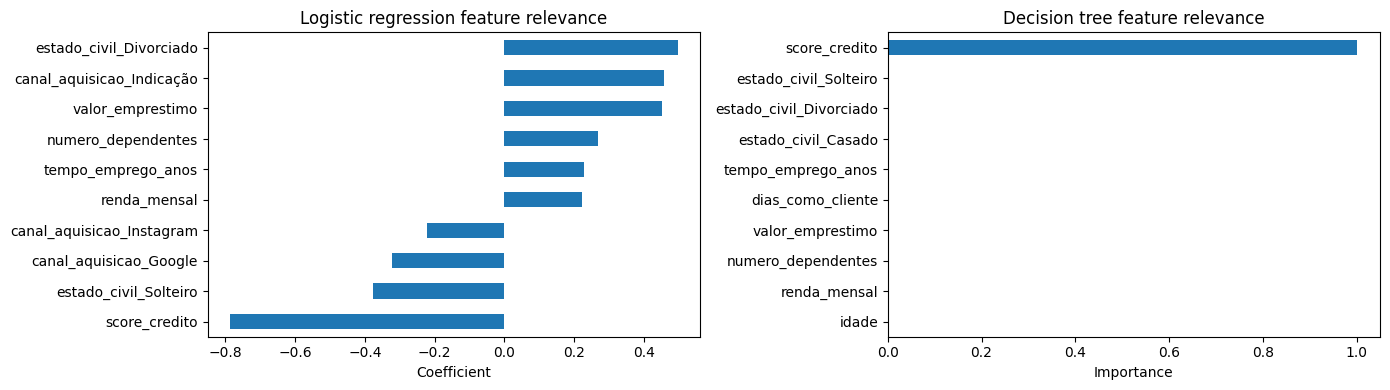

In [20]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline


def safe_roc_auc(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def evaluate_model(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_roc_auc(y_true, y_score),
    }


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression (normalized)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
    "Decision Tree (raw)": DecisionTreeClassifier(
        max_depth=3, random_state=RANDOM_STATE
    ),
}

cv_rows = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_raw, y), start=1):
    X_train, X_test = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for model_name, estimator in models.items():
        fitted_model = clone(estimator)
        fitted_model.fit(X_train, y_train)

        y_pred = fitted_model.predict(X_test)
        y_score = fitted_model.predict_proba(X_test)[:, 1]

        row = {"fold": fold, "model": model_name}
        row.update(evaluate_model(y_test, y_pred, y_score))
        cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows)

metrics_by_fold = cv_results.set_index(["model", "fold"]).sort_index()

metrics_summary = cv_results.groupby("model")[
    ["accuracy", "recall", "precision", "f1_score", "roc_auc"]
].agg(["mean", "std"])

metrics_summary.columns = [
    f"{metric}_{stat}" for metric, stat in metrics_summary.columns
]

# Refit on the full dataset only to inspect feature relevance after CV evaluation.
log_reg_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_final.fit(X_normalized, y)

tree_final = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_final.fit(X_raw, y)

log_relevance = pd.Series(
    log_reg_final.coef_[0],
    index=X_normalized.columns,
    name="coefficient",
).sort_values(key=lambda series: series.abs(), ascending=False)

tree_relevance = pd.Series(
    tree_final.feature_importances_,
    index=X_raw.columns,
    name="importance",
).sort_values(ascending=False)

display(metrics_by_fold)
display(metrics_summary)
display(log_relevance.to_frame().head(10))
display(tree_relevance.to_frame().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
log_relevance.head(10).sort_values().plot.barh(
    ax=axes[0], title="Logistic regression feature relevance"
)
tree_relevance.head(10).sort_values().plot.barh(
    ax=axes[1], title="Decision tree feature relevance"
)
axes[0].set_xlabel("Coefficient")
axes[1].set_xlabel("Importance")
plt.tight_layout()